# Seoul Bike Sharing Demand
## Exploratory Data Analysis

**Student Name:** Yaron Sher
**Student ID:**  211521067
**Course:** Introduction to Data Science
**Assignment:** Homework 1 – Exploratory Data Analysis



## Personal Motivation

ive been mountain biking for a few years now, so I wanted to do this Data Science assignment on a sport or a field of interest that is near n dear to my heart

the dataset I found *is not* exactly the same kind of extreme riding I usually do, but it is still about bikes, so for me that is close enough

because of that, I found this dataset more interesting to work with

## Setup

in this part, I will import the libraries and load the dataset

i will also display the first five rows to make sure the file was loaded correctly

In [1]:
import pandas as pd                        ##
import numpy as np                         ##  work with numbers
import matplotlib.pyplot as plt            ##  make graphs
import os                                  ##  work with files

In [2]:
# find the data file
from pathlib import Path                                          ##
file_name = "SeoulBikeData.csv"                                   ##
possible_paths = [Path("data") / file_name,Path("..") / "data" / file_name]   ##

# also check inside project folders
possible_paths.extend(Path.cwd().glob(f"*/data/{file_name}"))

# use the first path that exists
file_path = next((path for path in possible_paths if path.exists()),None)

# stop if the file was not found
if file_path is None:raise FileNotFoundError("SeoulBikeData.csv was not found inside a data folder.")
print("Dataset loaded from:", file_path.resolve())                ##

# load the csv file
bike_data = pd.read_csv(file_path,encoding="cp1252")
bike_data.head()                                                  ##                                            ##

Dataset loaded from: C:\Users\BAUZA\PyCharmMiscProject\Work_one_Yaron_sher_seoul\data\SeoulBikeData.csv


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 2. Dataset Selection

### 2.1 Dataset Requirements

before starting the analysis, I will check if the dataset meets the basic requirements of the assignment

In [3]:
# check dataset size and column types

number_of_rows, number_of_columns = bike_data.shape         ##
print("Number of rows:", number_of_rows)                    ##
print("Number of columns:", number_of_columns)              ##
print("\nColumn data types:")                               ##
print(bike_data.dtypes)                                     ##

Number of rows: 8760
Number of columns: 14

Column data types:
Date                             str
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                          str
Holiday                          str
Functioning Day                  str
dtype: object


the dataset contains 8,760 rows and 14 columns, so it meets the size requirements of the assignment

it also contains different variable types:

* numerical variables - rented bike count, temperature, humidity and rainfall
* time-related variables - date and hour
* categorical variables - season, holiday and functioning day

because of this, the dataset is suitable for the assignment

### 2.2 Dataset Source and Purpose

the dataset was downloaded from the UCI Machine Learning Repository

it contains the number of public bikes rented during each hour in Seoul. The dataset also includes weather information, date and time information, seasons, holidays and whether the bike rental system was working

the main purpose of the dataset is to understand and predict the number of bikes needed at different hours. This can help the bike sharing system keep enough bikes available and reduce waiting time for users

the UCI page does not clearly explain which organization originally collected the data or exactly how every measurement was collected. This is important because some details about the data collection process are unknown

**dataset name:** Seoul Bike Sharing Demand
**source:** UCI Machine Learning Repository
**file format:** CSV

## 3. Data Meta-Analysis

### 3.1 File Analysis

In this section, I will check some basic information about the file, such as its size, format and date range.

In [4]:
# get file size in kb
file_size_kb = os.path.getsize(file_path) / 1024           ##

# convert dates to datetime
date_values = pd.to_datetime(bike_data["Date"],format="%d/%m/%Y")

print("File name:", os.path.basename(file_path))           ##
print("File format: CSV")                                  ##
print("File size:", round(file_size_kb, 2), "KB")          ##
print("First date:", date_values.min())                    ##
print("Last date:", date_values.max())                     ##

File name: SeoulBikeData.csv
File format: CSV
File size: 590.01 KB
First date: 2017-12-01 00:00:00
Last date: 2018-11-30 00:00:00


the dataset is stored in a CSV file with a size of about 590 KB.

the file is quite small, so it can be loaded and analyzed without any special memory handling

the data covers a full year, from 1.12.2017 to 30.11.2018

the original creation date of the file is not included in the dataset, so it is unknown at this time of making this assignment

the purpose of the file is to store hourly bike rental information together with weather and time-related data

### 3.2 Data Structure

in this section, I will check the structure of the dataset

i will look at the number of rows and columns, the column names and the data type of each column

In [5]:
# check basic dataset structure
print("Number of rows:", bike_data.shape[0])            ##
print("Number of columns:", bike_data.shape[1])         ##

print("\nColumn names:")                                ##
for column_name in bike_data.columns:print("-", column_name)                             ##

print("\nDataset information:")                         ##
bike_data.info()                                        ##

Number of rows: 8760
Number of columns: 14

Column names:
- Date
- Rented Bike Count
- Hour
- Temperature(°C)
- Humidity(%)
- Wind speed (m/s)
- Visibility (10m)
- Dew point temperature(°C)
- Solar Radiation (MJ/m2)
- Rainfall(mm)
- Snowfall (cm)
- Seasons
- Holiday
- Functioning Day

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 

the dataset contains 8,760 rows and 14 columns

the column names explain the information stored in the dataset, but some of them contain spaces, brackets and special symbols. This may make the code harder to write later

most of the weather and rental columns were loaded as numerical values

the season, holiday and functioning day columns were loaded as object columns because they contain text

the date column was also loaded as an object. Since it represents a date, I will convert it to a datetime type later

#### cleaning up the Column Names :D

some of the original column names contain spaces, brackets and special symbols

i will rename them using shorter and clearer names. This will make the code easier to read and use later

In [6]:
# rename columns to make them easier to use

bike_data = bike_data.rename(                           ##
    columns={                                           ##
        "Date": "date",                                 ##
        "Rented Bike Count": "rented_count",            ##
        "Hour": "hour",                                 ##
        "Temperature(°C)": "temperature",               ##
        "Humidity(%)": "humidity",                      ##
        "Wind speed (m/s)": "wind_speed",               ##
        "Visibility (10m)": "visibility",               ##
        "Dew point temperature(°C)": "dew_point_temp",  ##
        "Solar Radiation (MJ/m2)": "solar_radiation",   ##
        "Rainfall(mm)": "rainfall",                     ##
        "Snowfall (cm)": "snowfall",                    ##
        "Seasons": "season",                            ##
        "Holiday": "holiday",                           ##
        "Functioning Day": "functioning_day"            ##
    }
)

bike_data.head()                                        ##

,date,rented_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall,season,holiday,functioning_day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


#### converting the Date Column

the date column is currently stored as text

i will convert it to a datetime type so I can use it later for time-based analysis

In [7]:
bike_data["date"] = pd.to_datetime(bike_data["date"],format="%d/%m/%Y") ##
bike_data.dtypes                                                        ##

date               datetime64[us]
rented_count                int64
hour                        int64
temperature               float64
humidity                    int64
wind_speed                float64
visibility                  int64
dew_point_temp            float64
solar_radiation           float64
rainfall                  float64
snowfall                  float64
season                        str
holiday                       str
functioning_day               str
dtype: object

as you can see the column names were changed successfully.

the date column was also converted to a datetime type. The other columns already have suitable data types for the next parts of the analysis.

#### column overview

to get a clearer view of the dataset, I will create a summary table for all the columns

the table will show the data type, the number of unique values and the number of missing values in each column

In [8]:
column_overview = pd.DataFrame({"data_type":bike_data.dtypes,"unique_values": bike_data.nunique(),"missing_values": bike_data.isnull().sum()})

column_overview                                        ##

,data_type,unique_values,missing_values
date,datetime64[us],365,0
rented_count,int64,2166,0
hour,int64,24,0
temperature,float64,546,0
humidity,int64,90,0
wind_speed,float64,65,0
visibility,int64,1789,0
dew_point_temp,float64,556,0
solar_radiation,float64,345,0
rainfall,float64,61,0


the dataset contains 14 columns, and none of them has missing values

the date column has 365 unique values, and the hour column has 24 unique values. This matches one full year with one row for every hour

the season column has 4 unique values, while the holiday and functioning day columns each have 2 unique values

the numerical weather columns have many unique values. This means they may be useful later when checking how weather conditions are related to the number of rented bikes

#### initial Discussion

the dataset looks more like operational data than research data

each row records the bike rental activity and weather conditions during a specific hour. This type of information can help the bike sharing system understand demand and plan how many bikes should be available

one possible limitation is that the dataset only covers Seoul and only one year. The results may be different in another city or during another year

there may also be other factors that affect bike rentals but are not included in the dataset, such as public events, traffic problems or changes in public transportation

## 4. data quality and completeness

### 4.1 missing data

missing values can affect the results of the analysis

first, I will check how many missing values exist in each column and what percentage of the dataset they represent

In [9]:
# check missing values
missing_summary = pd.DataFrame({"missing_count": bike_data.isnull().sum(),"missing_percent": (bike_data.isnull().mean() * 100).round(2)}) ##
missing_summary                                  ##

,missing_count,missing_percent
date,0,0.0
rented_count,0,0.0
hour,0,0.0
temperature,0,0.0
humidity,0,0.0
wind_speed,0,0.0
visibility,0,0.0
dew_point_temp,0,0.0
solar_radiation,0,0.0
rainfall,0,0.0


In [10]:
total_missing_values = bike_data.isnull().sum().sum()   ##
print("Total missing values:", total_missing_values)    ##

Total missing values: 0


the dataset does not contain any missing values

because there are no missing values, there is no missing data pattern to analyze. The missing data is not random or structured because no values are missing

there is also no need to remove rows or fill any values

if missing values were found in the numerical weather columns, I would first check the values from nearby hours. Depending on the column, I could use the median or interpolation. For categorical columns, I could use the most common value, but only after checking why the data is missing

### 4.2 Duplicates

duplicate rows may cause the same observation to be counted more than once

first, I will check for full duplicates, where all the values in two rows are the same

i will also check for partial duplicates using the date and hour columns. In this dataset, each combination of date and hour should represent one unique observation

In [11]:
# check full duplicates
full_duplicates = bike_data.duplicated().sum()                 ##
# check if the same date and hour appear twice
time_duplicates = bike_data.duplicated(subset=["date", "hour"]).sum()     ##
print("Full duplicate rows:", full_duplicates)                 ##
print("Duplicate date and hour combinations:", time_duplicates)##

Full duplicate rows: 0
Duplicate date and hour combinations: 0


no full duplicate rows were found in the dataset

there are also no repeated combinations of date and hour. This means that every hourly observation appears only once

some values, such as the season or weather measurements, appear many times, but this is expected and does not mean that the rows are duplicates

since no duplicates were found, there is no need to remove any rows

### 4.3 Suspicious Values

In this section, I will check if the dataset contains values that look impossible or unusual

I will check the minimum and maximum values, the number of zeros and the number of negative values in each numerical column

In [12]:
# get all numerical columns
numerical_columns = bike_data.select_dtypes(include="number").columns  ##

# check for values that may look unusual
suspicious_values_summary = pd.DataFrame({                             ##
    "minimum": bike_data[numerical_columns].min(),                     ##
    "maximum": bike_data[numerical_columns].max(),                     ##
    "zero_count": (bike_data[numerical_columns] == 0).sum(),           ##
    "negative_count": (bike_data[numerical_columns] < 0).sum()         ##
})

suspicious_values_summary                                              ##

,minimum,maximum,zero_count,negative_count
rented_count,0.0,3556.00,295,0
hour,0.0,23.00,365,0
temperature,-17.8,39.40,21,1433
humidity,0.0,98.00,17,0
wind_speed,0.0,7.40,74,0
visibility,27.0,2000.00,0,0
dew_point_temp,-30.6,27.20,60,3138
solar_radiation,0.0,3.52,4300,0
rainfall,0.0,35.00,8232,0
snowfall,0.0,8.80,8317,0


In [13]:
# check why some hours have zero rentals
zero_rental_rows = bike_data[bike_data["rented_count"] == 0]           ##
print("Rows with zero rented bikes:", len(zero_rental_rows))           ##
print("\nFunctioning day values for zero rentals:")                    ##
print(zero_rental_rows["functioning_day"].value_counts())              ##

Rows with zero rented bikes: 295

Functioning day values for zero rentals:
functioning_day
No    295
Name: count, dtype: int64


In [14]:
# check rows with zero humidity
zero_humidity_rows = bike_data[bike_data["humidity"] == 0]             ##
print("Rows with zero humidity:", len(zero_humidity_rows))             ##
zero_humidity_rows[["date", "hour", "temperature", "humidity"]].head() ##

Rows with zero humidity: 17


,date,hour,temperature,humidity
4063,2018-05-19,7,11.4,0
4106,2018-05-21,2,13.9,0
4107,2018-05-21,3,13.0,0
4108,2018-05-21,4,12.4,0
4109,2018-05-21,5,11.9,0


In [15]:
# choose the categorical columns
categorical_columns = ["season","holiday","functioning_day"]           ##

# check for common placeholder values
placeholder_values = ["Unknown", "N/A", "NA", "-", "?"]                ##
for column_name in categorical_columns:                                ##
    placeholder_count = bike_data[column_name].isin(placeholder_values).sum() ##
    print(column_name, "placeholder values:", placeholder_count)       ##

season placeholder values: 0
holiday placeholder values: 0
functioning_day placeholder values: 0


the numerical values are mostly inside reasonable ranges

the temperature and dew point temperature columns contain negative values, but this is normal during cold winter days

zero values in rainfall, snowfall and solar radiation are also expected. For example, rainfall and snowfall are usually zero when there is no rain or snow, and solar radiation can be zero during the night

there are 295 rows where the rented bike count is zero. All of these rows are marked as non-functioning days, so these values are meaningful and should not be removed

the humidity column contains a small number of zero values. A humidity value of zero is unusual, so these rows may contain a measurement problem. Since there is not enough information to prove that they are incorrect, I will keep them but mention them as suspicious values

no common placeholder values were found in the categorical columns

### 4.4 cardinality

Ccardinality is the number of unique values in a column

in this section, I will check if any columns contain only one value and which columns contain many different values

In [16]:
# check unique values in each column
cardinality_summary = pd.DataFrame({"unique_values": bike_data.nunique(),"unique_percent": (bike_data.nunique() / len(bike_data) * 100).round(2)}) ##

# sort by unique values
cardinality_summary = cardinality_summary.sort_values(by="unique_values",ascending=False) ##
cardinality_summary                                             ##

,unique_values,unique_percent
rented_count,2166,24.73
visibility,1789,20.42
dew_point_temp,556,6.35
temperature,546,6.23
date,365,4.17
solar_radiation,345,3.94
humidity,90,1.03
wind_speed,65,0.74
rainfall,61,0.70
snowfall,51,0.58


In [17]:
# find columns with only one value
constant_columns = [                                            ##
    column_name                                                 ##
    for column_name in bike_data.columns                        ##
    if bike_data[column_name].nunique() == 1]

print("Columns with only one unique value:", constant_columns)  ##

Columns with only one unique value: []


no columns contain only one unique value. This means that every column has some variation and may contain useful information

the rented_count and visibility columns have many unique values. This makes sense because they are numerical measurements that can change between hours

the date column has 365 unique values because the dataset covers 365 days. Each date appears 24 times, once for every hour

the season, holiday and functioning_day columns have low cardinality. This is expected because they are categorical columns with a small number of possible values

no single column is unique for every row. However, the combination of date and hour is unique and represents one hourly observation

## 5. univariate analysis

### 5.1 numerical variables

in this section, I will analyze each numerical variable separately

first, I will calculate basic statistical measures such as the mean, median, standard deviation, minimum, maximum, quartiles, MAD, IQR and skewness

In [18]:
# choose numerical columns
numerical_columns = [                                     ##
    "rented_count",                                       ##
    "temperature",                                        ##
    "humidity",                                           ##
    "wind_speed",                                         ##
    "visibility",                                         ##
    "dew_point_temp",                                     ##
    "solar_radiation",                                    ##
    "rainfall",                                           ##
    "snowfall"                                            ##
]

# calculate the main statistics
numerical_summary = pd.DataFrame({                        ##
    "mean": bike_data[numerical_columns].mean(),          ##
    "median": bike_data[numerical_columns].median(),      ##
    "std": bike_data[numerical_columns].std(),
    # calculate mad using the median
    "mad": bike_data[numerical_columns].apply(            ##
        lambda column: (column - column.median()).abs().median()                                  ##
    ),
    "minimum": bike_data[numerical_columns].min(),        ##
    "q1": bike_data[numerical_columns].quantile(0.25),    ##
    "q3": bike_data[numerical_columns].quantile(0.75),    ##
    "maximum": bike_data[numerical_columns].max(),        ##
    "skewness": bike_data[numerical_columns].skew()       ##
})

# calculate iqr
numerical_summary["iqr"] = (                              ##
        numerical_summary["q3"]-numerical_summary["q1"])

# arrange the columns
numerical_summary = numerical_summary[                    ##
    [
        "mean",                                           ##
        "median",                                         ##
        "std",                                            ##
        "mad",                                            ##
        "minimum",                                        ##
        "q1",                                             ##
        "q3",                                             ##
        "maximum",                                        ##
        "iqr",                                            ##
        "skewness"                                        ##
    ]
]

numerical_summary.round(2)                                ##
## median(|value - median|)

,mean,median,std,mad,minimum,q1,q3,maximum,iqr,skewness
rented_count,704.60,504.50,645.00,373.50,0.0,191.0,1065.25,3556.00,874.25,1.15
temperature,12.88,13.70,11.94,9.40,-17.8,3.5,22.50,39.40,19.00,-0.20
humidity,58.23,57.00,20.36,16.00,0.0,42.0,74.00,98.00,32.00,0.06
wind_speed,1.72,1.50,1.04,0.70,0.0,0.9,2.30,7.40,1.40,0.89
visibility,1436.83,1698.00,608.30,302.00,27.0,940.0,2000.00,2000.00,1060.00,-0.70
dew_point_temp,4.07,5.10,13.06,9.70,-30.6,-4.7,14.80,27.20,19.50,-0.37
solar_radiation,0.57,0.01,0.87,0.01,0.0,0.0,0.93,3.52,0.93,1.50
rainfall,0.15,0.00,1.13,0.00,0.0,0.0,0.00,35.00,0.00,14.53
snowfall,0.08,0.00,0.44,0.00,0.0,0.0,0.00,8.80,0.00,8.44


#### 5.1.2 main findings from the numerical summary

the rented bike count has a mean of about 705 bikes and a median of about 505 bikes

the mean is higher than the median, and the skewness is 1.15. This shows that the rented bike count is skewed to the right. Most hours have a lower number of rentals, while some hours have a very high number of rentals

the temperature and humidity values are close to a symmetric distribution because their skewness values are close to zer

wind speed and solar radiation are skewed to the right. This means that most values are relatively low, with a smaller number of high values

visibility is slightly skewed to the left. Many observations have high visibility values, including the maximum value of 2,000

rainfall and snowfall have very high positive skewness values. Their median, first quartile and third quartile are all zero. This means that during most hours there was no rain or snow, while only a small number of hours had high values

the rented bike count has a large standard deviation and IQR, which shows that the number of rented bikes changes a lot between different hours

#### 5.1.3 distribution of numerical variables

the statistical table gives useful information, but graphs can make the distributions easier to understand

i will use histograms to see where most values are located and whether the variables are skewed

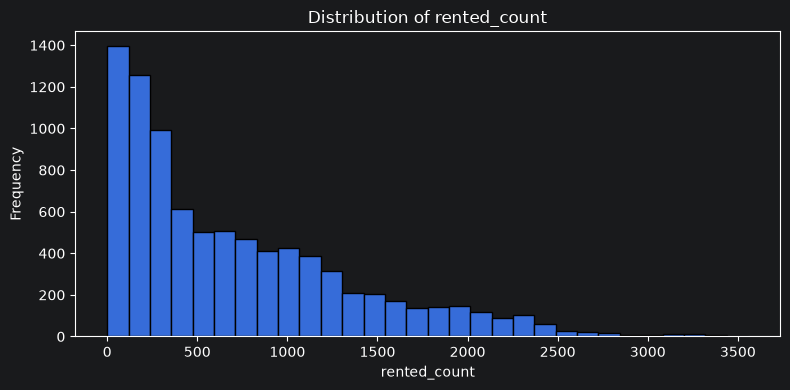

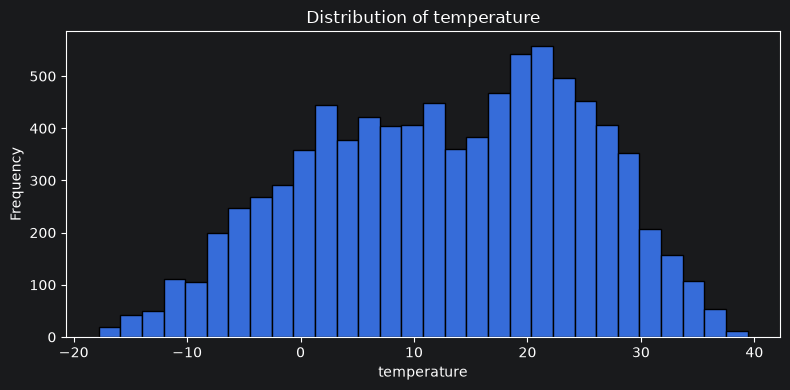

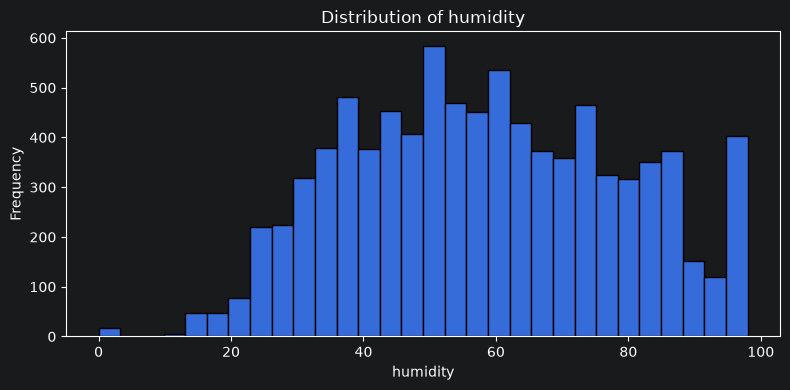

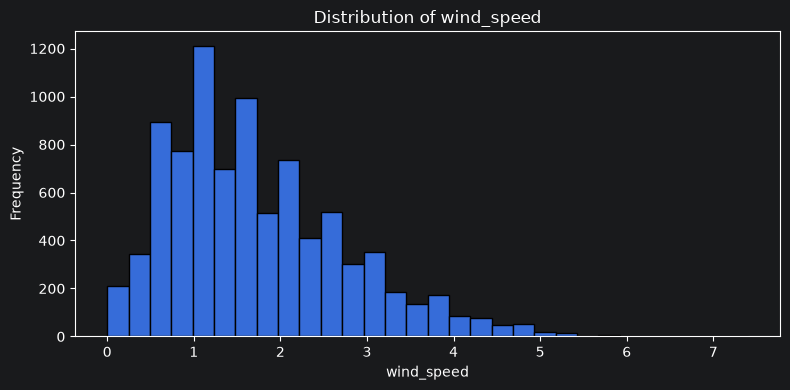

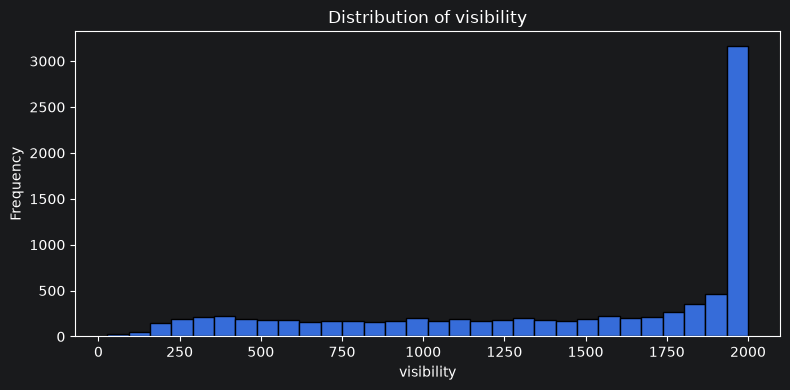

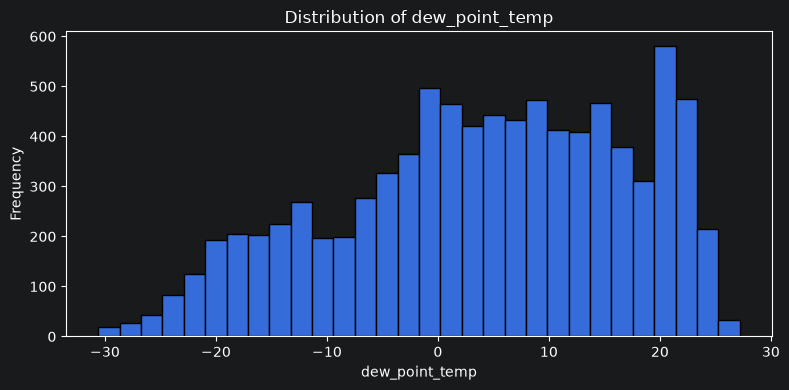

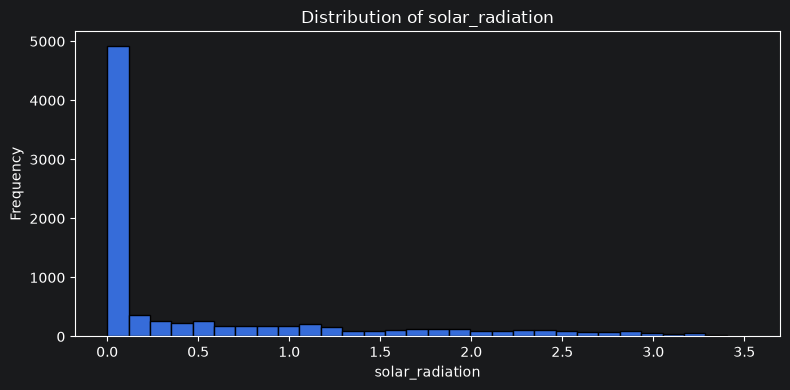

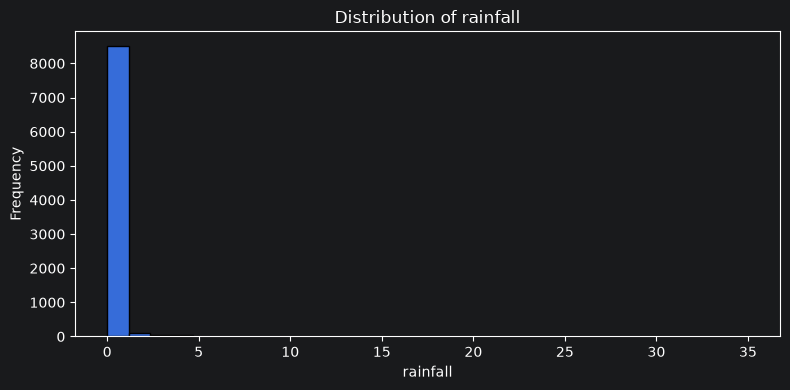

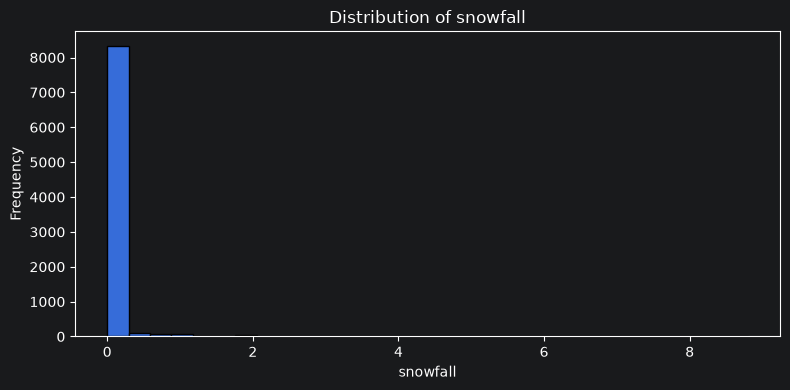

In [19]:
# make a histogram for each numerical column
for column_name in numerical_columns:             ##
    plt.figure(figsize=(8, 4))                    ##

    plt.hist(bike_data[column_name],bins=30,edgecolor="black")

    # add titles and labels
    plt.title(f"Distribution of {column_name}")   ##
    plt.xlabel(column_name)                       ##
    plt.ylabel("Frequency")                       ##
    plt.tight_layout()                            ##
    plt.show()                                    ##

#### rented bike count distribution

since rented_count is the main variable in the dataset, I will display its distribution separately

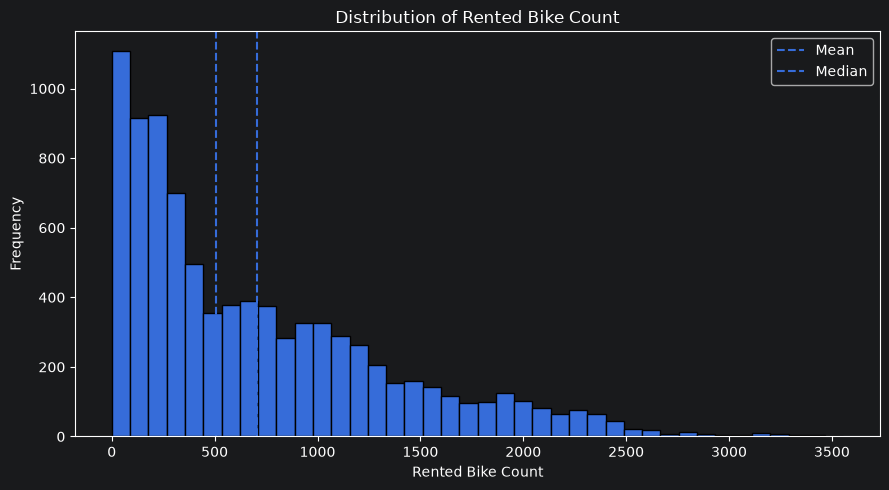

In [20]:
# make histogram for rented bike count
plt.figure(figsize=(9, 5))                        ##
plt.hist(bike_data["rented_count"],bins=40,edgecolor="black")

# add mean and median lines
plt.axvline(bike_data["rented_count"].mean(),linestyle="--",label="Mean")

plt.axvline(bike_data["rented_count"].median(),linestyle="--",label="Median")

# add titles and labels
plt.title("Distribution of Rented Bike Count")    ##
plt.xlabel("Rented Bike Count")                   ##
plt.ylabel("Frequency")                           ##
plt.legend()                                      ##
plt.tight_layout()                                ##
plt.show()                                        ##

#### 5.1.4 findings from the histograms

the histograms show that the numerical variables do not all have the same type of distribution

the rented bike count is clearly skewed to the right. Most hours have a relatively low or medium number of rentals, while a smaller number of hours have very high rental counts. The mean is higher than the median, which also supports this result

temperature and dew point temperature are more balanced than most of the other variables. Their distributions are not perfectly normal, probably because the dataset contains different seasons

humidity is spread across a wide range of values and does not show a strong skew

wind speed is skewed to the right. Most hours have low or medium wind speeds, while high wind speeds are less common

visibility is skewed to the left. A large number of observations have a visibility value of 2,000. This may mean that 2,000 is the maximum value recorded by the system

solar radiation contains many zero values because solar radiation is normally zero during nighttime. The remaining values are spread to the right

rainfall and snowfall are strongly skewed to the right. Most hours have no rain or snow, while only a small number of hours have positive values

overall, the graphs support the skewness values found in the descriptive statistics table

#### 5.1.5 outlier detection

outliers are values that are far away from most of the other observations

i will use three different methods to detect possible outliers:

-  the IQR method
-  the Z-score method
-  the modified Z-score method, which is based on the median and MAD

a value detected as an outlier is not always incorrect. It may represent a rare but real event

In [21]:
# store the outlier results
outlier_results = []                                  ##

for column_name in numerical_columns:                 ##
    column_data = bike_data[column_name]              ##

    # iqr method
    q1 = column_data.quantile(0.25)                   ##
    q3 = column_data.quantile(0.75)                   ##
    iqr = q3 - q1                                     ##
    iqr_lower_limit = q1 - 1.5 * iqr                  ##
    iqr_upper_limit = q3 + 1.5 * iqr                  ##
    iqr_outliers = ((column_data < iqr_lower_limit) |(column_data > iqr_upper_limit)).sum() ##

    # z score method
    mean_value = column_data.mean()                   ##
    std_value = column_data.std()                     ##

    z_scores = (column_data - mean_value) / std_value ##
    z_score_outliers = (z_scores.abs() > 3 ).sum()    ##

    # modified z score method
    median_value = column_data.median()               ##
    mad_value = (column_data - median_value).abs().median()  ##

    # avoid dividing by zero
    if mad_value > 0:                                 ##
        modified_z_scores = (0.6745 * (column_data - median_value)/mad_value) ##

        modified_z_outliers = (
                modified_z_scores.abs() > 3.5).sum()                                       ##
    else:                                             ##
        modified_z_outliers = np.nan                  ##

    outlier_results.append({"column": column_name,"iqr_outliers": iqr_outliers,"z_score_outliers": z_score_outliers,"modified_z_outliers": modified_z_outliers})

outlier_summary = pd.DataFrame(outlier_results)       ##
outlier_summary                                       ##

,column,iqr_outliers,z_score_outliers,modified_z_outliers
0,rented_count,158,67,123.0
1,temperature,0,0,0.0
2,humidity,0,0,0.0
3,wind_speed,161,63,28.0
4,visibility,0,0,50.0
5,dew_point_temp,0,0,0.0
6,solar_radiation,641,85,4019.0
7,rainfall,528,94,NaN
8,snowfall,443,173,NaN


#### 5.1.6 findings from the outlier detection

the three methods found different numbers of possible outliers

the rented bike count contains some high values that are far from most of the observations. These values may represent very busy hours, so they should not automatically be removed

temperature, humidity and dew point temperature did not contain outliers according to the three methods

wind speed contains a small number of high values. These may represent unusually windy hours, but they are still possible measurements

the methods gave very different results for solar radiation. The modified Z-score marked many values as outliers because the MAD is very small and many observations are close to zero. Because of this, the modified Z-score is not very useful for this variable

rainfall and snowfall contain many zero values and only a small number of positive values. This causes the IQR method to mark most positive values as outliers.

the modified Z-score could not be calculated for rainfall and snowfall because their MAD is zero

overall, the detected outliers look more like rare weather conditions or busy rental hours than clear data errors. For this reason, I will keep them in the dataset

### 5.2 categorical variables

in this section, I will analyze the categorical variables separately

i will check the number of observations in each category, the percentage of the dataset and the most common values

In [22]:
# choose categorical columns
categorical_columns = ["season", "holiday" , "functioning_day"]                          ##

# show count and percent for each category
for column_name in categorical_columns:                                                  ##
    category_summary = pd.DataFrame({"count": bike_data[column_name].value_counts(),"percent": (bike_data[column_name].value_counts(normalize=True) * 100 ).round(2)})

    print("\nColumn:", column_name)                                                      ##
    display(category_summary)                                                            ##


Column: season


,count,percent
season,,
Spring,2208,25.21
Summer,2208,25.21
Autumn,2184,24.93
Winter,2160,24.66



Column: holiday


,count,percent
holiday,,
No Holiday,8328,95.07
Holiday,432,4.93



Column: functioning_day


,count,percent
functioning_day,,
Yes,8465,96.63
No,295,3.37


#### 5.2.1 findings from the categorical variables

the season column is almost evenly divided between the four seasons. Each season represents about 25% of the dataset. This makes the seasonal comparison more balanced

most observations are marked as No Holiday. Holidays represent only 4.93% of the dataset

most observations are also functioning days. Only 3.37% of the rows represent days when the bike rental system was not working

holiday and non-functioning day values are relatively rare, but they are still important. They may help explain changes in the number of rented bikes, so they should not be removed or combined with other categories

#### 5.2.2 most common categories and coverage

i will check the three most common values in each categorical column

i will also find the smallest number of categories needed to cover at least 90% of the observations

In [23]:
# set top k and target percent
top_k = 3                                                                                      ##
target_percent = 90                                                                            ##

for column_name in categorical_columns:
    # get category percentages
    value_percentages = (bike_data[column_name].value_counts(normalize=True).mul(100))
    # get the most common categories
    top_values = value_percentages.head(top_k)
    # calculate cumulative percent
    cumulative_percentages = value_percentages.cumsum()
    # find how many categories are needed to reach the target
    required_categories = (cumulative_percentages < target_percent).sum() + 1                  ##
    covering_values = value_percentages.head(required_categories)                              ##
    print("\nColumn:", column_name)                                                            ##
    print(f"\nTop {top_k} categories:")                                                        ##
    display(top_values.to_frame(name="percent"))                                               ##
    print(f"Minimum categories needed to cover " f"{target_percent}%: {required_categories}")  ##
    display(covering_values.to_frame(name="percent"))                                          ##


Column: season

Top 3 categories:


,percent
season,
Spring,25.205479
Summer,25.205479
Autumn,24.931507


Minimum categories needed to cover 90%: 4


,percent
season,
Spring,25.205479
Summer,25.205479
Autumn,24.931507
Winter,24.657534



Column: holiday

Top 3 categories:


...

,percent
holiday,
No Holiday,95.068493



Column: functioning_day

Top 3 categories:


,percent
functioning_day,
Yes,96.63242
No,3.36758


Minimum categories needed to cover 90%: 1


,percent
functioning_day,
Yes,96.63242


#### 5.2.3 category coverage and rare categories

the three most common seasons cover about 75% of the dataset. To cover at least 90%, all four seasons are needed. This happens because the dataset is almost evenly divided between the seasons

for the holiday column, the No Holiday category alone covers about 95% of the observations

for the functioning_day column, the Yes category alone covers about 97% of the observations

holiday and non-functioning days are rare compared to the other categories. However, they may have an important effect on bike rentals, so I will keep them as separate categories

the most common value does not represent the season column very well because all four seasons have similar percentages. For the holiday and functioning_day columns, the most common value represents most of the dataset, but it may hide the behavior of the smaller categories

## 6. correlations and relationships

### 6.1 numerical-numerical relationships

in this section, i will check the relationships between the numerical variables

i will use three correlation methods:

- Pearson checks linear relationships between numerical values
- Spearman checks whether two variables generally increase or decrease together, based on their ranks
- Kendall also uses ranks, but it compares the order of pairs of observations

values close to 1 show a positive relationship, values close to -1 show a negative relationship, and values close to 0 show a weak relationship

the hour column is included, but it should be interpreted carefully. Hour is a time variable, and hours 23 and 0 are close in time even though their numerical values are far apart

In [24]:
# choose columns for correlation
correlation_columns = ["rented_count","hour","temperature","humidity","wind_speed","visibility","dew_point_temp","solar_radiation","rainfall","snowfall"]                                                      ##
# calculate the three correlation methods
pearson_correlation = bike_data[correlation_columns].corr(method="pearson")  ##
spearman_correlation = bike_data[correlation_columns].corr(method="spearman")##
kendall_correlation = bike_data[correlation_columns].corr(method="kendall")  ##

#### 6.1.1 correlation with rented bike count

i will compare the correlation between rented_count and the other numerical variables using the three methods.

In [25]:
# compare the correlations with rented count
rental_correlation_comparison = pd.DataFrame({                                                         ##
"pearson": pearson_correlation["rented_count"],"spearman": spearman_correlation["rented_count"],"kendall": kendall_correlation["rented_count"]})

# remove rented count from the comparison
rental_correlation_comparison = (rental_correlation_comparison.drop(index="rented_count"))             ##

# sort by the strongest pearson correlation
correlation_order = (rental_correlation_comparison["pearson"].abs().sort_values(ascending=False).index)
rental_correlation_comparison.loc[correlation_order].round(3)                                    ##

,pearson,spearman,kendall
temperature,0.539,0.565,0.391
hour,0.410,0.389,0.272
dew_point_temp,0.380,0.374,0.252
solar_radiation,0.262,0.382,0.274
humidity,-0.200,-0.221,-0.150
visibility,0.199,0.176,0.123
snowfall,-0.142,-0.221,-0.178
rainfall,-0.123,-0.282,-0.229
wind_speed,0.121,0.148,0.101


#### 6.1.2 findings from the correlation comparison

temperature has the strongest positive relationship with rented bike count in all three methods

this suggests that bike rentals usually increase when the temperature increases

hour also has a positive correlation with rented bike count. However, this result should be interpreted carefully because the relationship between hour and rentals may not be linear. For example, there may be separate peaks in the morning and evening

dew point temperature also has a positive relationship with rentals. This is reasonable because dew point temperature is related to the regular temperature

solar radiation has a positive relationship with rentals. Its Spearman correlation is higher than its Pearson correlation, which may mean that the relationship is not perfectly linear

humidity has a weak negative relationship with rented bike count. This means that higher humidity is usually connected with fewer rentals, but the relationship is not very strong

rainfall and snowfall also have negative relationships with rented bike count. The Spearman and Kendall results are stronger than the Pearson result for rainfall. This may happen because rainfall contains many zero values and a small number of high values

wind speed and visibility have only weak relationships with rented bike count

the Kendall values are generally smaller than the Pearson and Spearman values. This is expected because Kendall uses the order of pairs and usually gives smaller correlation values

#### 6.1.3 correlation matrices

i will use heatmaps to display the correlation matrices

the heatmaps make it easier to find positive and negative relationships between all the numerical variables

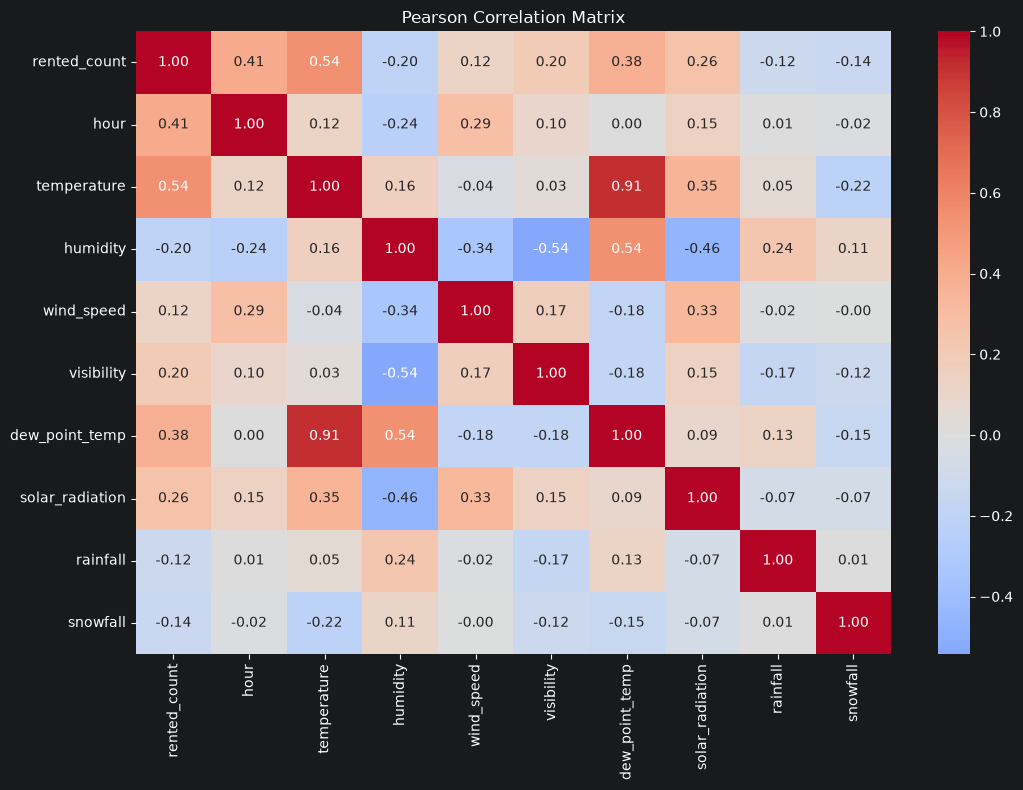

In [26]:
import seaborn as sns

# make pearson correlation heatmap
plt.figure(figsize=(11, 8))                    ##
                                               ##
sns.heatmap(pearson_correlation,annot=True,fmt=".2f",cmap="coolwarm",center=0)

# add title and fix layout
plt.title("Pearson Correlation Matrix")        ##
plt.tight_layout()                             ##
plt.show()                                     ##

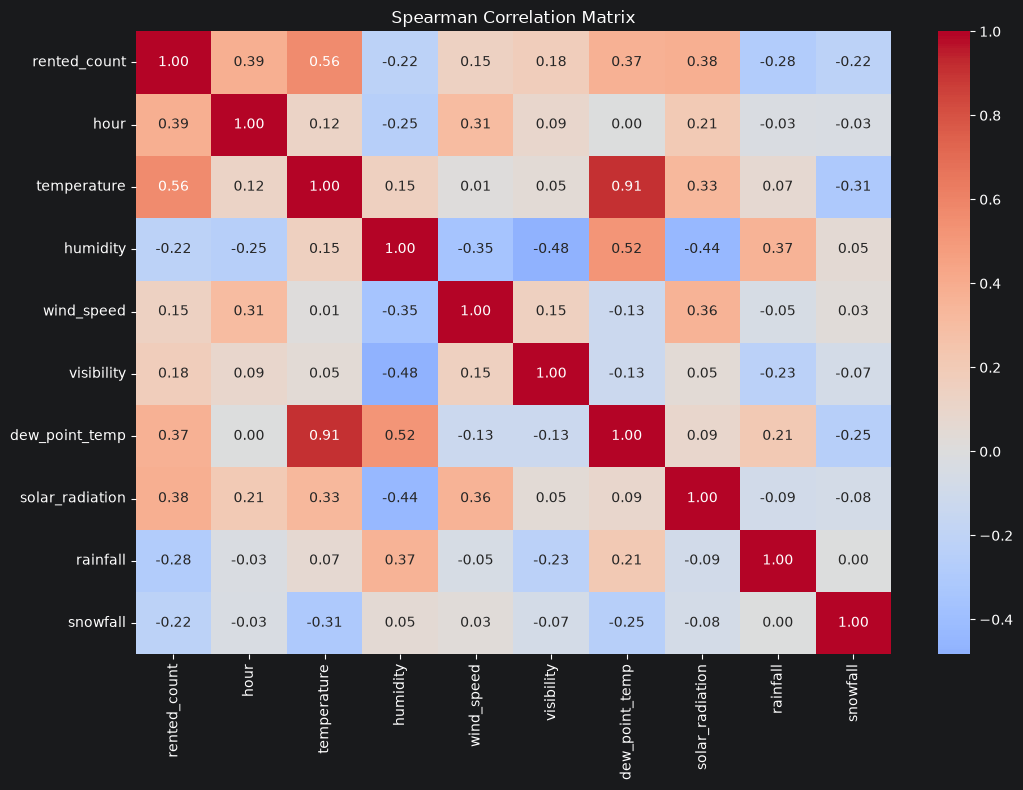

In [27]:
# make spearman correlation heatmap
plt.figure(figsize=(11, 8))                    ##
sns.heatmap(spearman_correlation,annot=True,fmt=".2f",cmap="coolwarm",center=0) ##

# add title and fix layout
plt.title("Spearman Correlation Matrix")       ##
plt.tight_layout()                             ##
plt.show()                                     ##

#### 6.1.4 findings from the correlation matrices

the strongest relationship in the matrix is between temperature and dew point temperature, with a Pearson correlation of about 0.91

this is expected because dew point temperature is strongly connected to the regular temperature

humidity and visibility have a negative correlation of about -0.54. This means that higher humidity usually appears together with lower visibility

humidity also has a negative relationship with solar radiation. Sunny hours usually have lower humidity than cloudy or rainy hours

some weather variables are related to each other, so they may contain similar information

the correlation matrix shows relationships between variables, but it does not prove that one variable causes another

### 6.2 categorical relationships

#### 6.2.1 frequency tables

in this section, i will check the relationships between the categorical variables

i will use frequency tables to compare season, holiday and functioning day

In [28]:
# choose categorical pairs
categorical_pairs = [("season", "holiday"),("season", "functioning_day"),("holiday", "functioning_day")] ##

for first_column, second_column in categorical_pairs:                            ##
    # make count table
    count_table = pd.crosstab(bike_data[first_column],bike_data[second_column])  ##
    # make percentage table
    percent_table = pd.crosstab(bike_data[first_column],bike_data[second_column],normalize="index").mul(100).round(2)    ##

    print(f"\nCount table: {first_column} and {second_column}")                  ##
    display(count_table)                                                         ##

    print(f"Row percentages: {first_column} and {second_column}")                ##
    display(percent_table)                                                       ##


Count table: season and holiday


holiday,Holiday,No Holiday
season,,
Autumn,120,2064
Spring,72,2136
Summer,48,2160
Winter,192,1968


Row percentages: season and holiday


holiday,Holiday,No Holiday
season,,
Autumn,5.49,94.51
Spring,3.26,96.74
Summer,2.17,97.83
Winter,8.89,91.11



Count table: season and functioning_day


...

functioning_day,No,Yes
season,,
Autumn,11.31,88.69
Spring,2.17,97.83
Summer,0.00,100.00
Winter,0.00,100.00



Count table: holiday and functioning_day


functioning_day,No,Yes
holiday,,
Holiday,24,408
No Holiday,271,8057


Row percentages: holiday and functioning_day


functioning_day,No,Yes
holiday,,
Holiday,5.56,94.44
No Holiday,3.25,96.75


#### 6.2.2 findings from the frequency tables

the percentage of holidays is different between the seasons

winter has the highest percentage of holidays, with about 8.89%, while summer has the lowest percentage, with about 2.17%

non-functioning days only appear during autumn and spring in this dataset. About 11.31% of the autumn observations are non-functioning days, compared to 2.17% in spring

all observations during summer and winter are marked as functioning days

non-functioning days are slightly more common during holidays than during regular days. However, the difference is not very large

these tables show that the categorical variables are not completely independent, but they do not explain the number of rented bikes by themselves

#### 6.2.3 binning the rented bike count

to compare the rented bike count with categorical variables, I will divide it into three groups:

- low rental demand
- medium rental demand
- high rental demand

i will use quantile-based bins so that each group contains about one third of the observations

In [29]:
# split rental count into three levels
bike_data["rental_level"], rental_bins = pd.qcut(bike_data["rented_count"],q=3,labels=["Low", "Medium", "High"],retbins=True) ##

# show the bin limits and amount in each group
print("Rental count bin limits:")                         ##
print(rental_bins)                                        ##

print("\nNumber of observations in each rental level:")   ##
print(bike_data["rental_level"].value_counts())           ##

Rental count bin limits:
[   0.  264.  861. 3556.]

Number of observations in each rental level:
rental_level
Low       2926
High      2918
Medium    2916
Name: count, dtype: int64


In [30]:
# compare rental levels for each category
for column_name in categorical_columns:                   ##
    rental_level_table = pd.crosstab(bike_data[column_name],bike_data["rental_level"],normalize="index").mul(100).round(2)                                   ##
    # show percentages for each group
    print(f"\nRental level percentages by {column_name}:")
    display(rental_level_table)                           ##


Rental level percentages by season:


rental_level,Low,Medium,High
season,,,
Autumn,26.65,29.17,44.18
Spring,29.98,34.06,35.96
Summer,11.96,35.78,52.26
Winter,65.65,34.12,0.23



Rental level percentages by holiday:


rental_level,Low,Medium,High
holiday,,,
Holiday,53.70,23.38,22.92
No Holiday,32.35,33.80,33.85



Rental level percentages by functioning_day:


rental_level,Low,Medium,High
functioning_day,,,
No,100.00,0.00,0.00
Yes,31.08,34.45,34.47


#### 6.2.4 findings from the rental level tables

the rental levels are clearly different between the seasons

summer has the highest percentage of high rental demand, with about 52%. Autumn also has a relatively high percentage of high demand

winter is very different from the other seasons. About 66% of winter observations are in the low rental group, and almost none are in the high rental group

spring is more balanced, although high and medium rental levels are slightly more common than low demand

during holidays, about 54% of the observations are in the low rental group. On regular days, the three rental levels are almost evenly divided. This suggests that bike demand is usually lower during holidays

all non-functioning observations are in the low rental group. This makes sense because no bikes were rented when the system was not operating

the rental levels were created using quantiles, so the groups represent relative low, medium and high demand inside this dataset

### 6.3 data visualizations

#### 6.3.1 scatterplot

i will use a scatterplot to check the relationship between temperature and rented bike count

each point represents one hourly observation

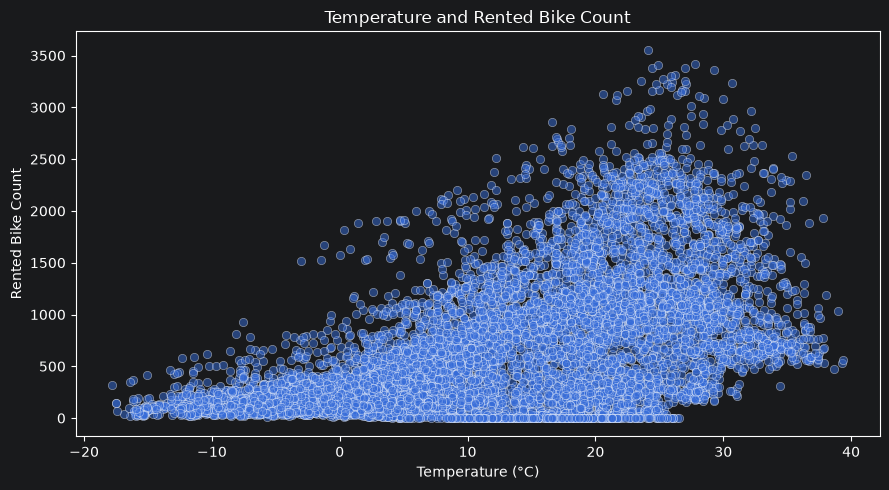

In [31]:
# make scatter plot for temperature and rentals
plt.figure(figsize=(9, 5))                                       ##

sns.scatterplot(data=bike_data,x="temperature",y="rented_count",alpha=0.5)

# add titles and labels
plt.title("Temperature and Rented Bike Count")                   ##
plt.xlabel("Temperature (°C)")                                   ##
plt.ylabel("Rented Bike Count")                                  ##
plt.tight_layout()                                               ##
plt.show()                                                       ##

the scatterplot shows a general positive relationship between temperature and rented bike count

higher rental counts appear more often during warmer temperatures. However, the points are widely spread, so temperature alone does not fully explain bike demand

there are also many observations with zero rentals at different temperatures. Some of these observations may belong to non-functioning days

#### 6.3.2 bar chart

I will use a bar chart to compare the average rented bike count between the four seasons

This makes it easier to see which seasons have higher or lower bike demand

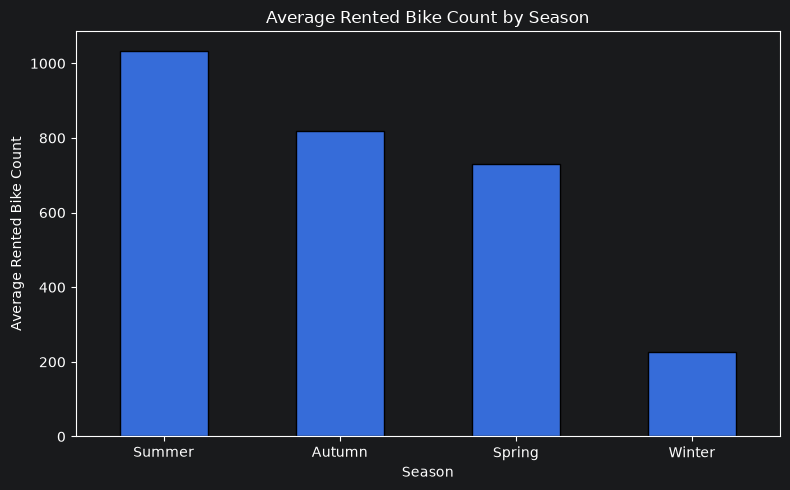

season
Summer    1034.07
Autumn     819.60
Spring     730.03
Winter     225.54
Name: rented_count, dtype: float64

In [32]:
# calculate average rentals for each season
average_rentals_by_season = (bike_data.groupby("season")["rented_count"].mean().sort_values(ascending=False))

# make a bar chart
plt.figure(figsize=(8, 5))                                  ##
average_rentals_by_season.plot(kind="bar",edgecolor="black")

plt.title("Average Rented Bike Count by Season")            ##
plt.xlabel("Season")                                        ##
plt.ylabel("Average Rented Bike Count")                     ##
plt.xticks(rotation=0)                                      ##
plt.tight_layout()                                          ##
plt.show()                                                  ##
average_rentals_by_season.round(2)                          ##

the bar chart shows that the average bike demand is highest during summer

autumn also has a relatively high average number of rentals, while winter has the lowest average

this matches the rental level table from the previous section, where winter contained mostly low-demand observations

season appears to have an important relationship with bike rental demand... however, season also includes changes in temperature, rainfall and daylight, so the difference may be connected to several factors

#### 6.3.3 boxplot

i will use a boxplot to compare the distribution of rented bike counts between the seasons

the boxplot shows the median, the middle 50% of the values and possible outliers

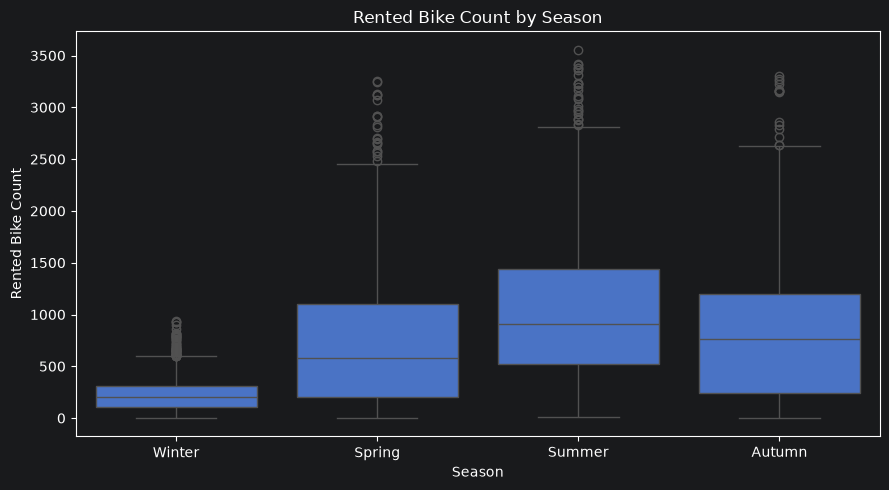

In [33]:
# set season order
season_order = ["Winter","Spring","Summer","Autumn"]

# make boxplot by season
plt.figure(figsize=(9, 5))                                        ##
sns.boxplot(data=bike_data,x="season",y="rented_count",order=season_order)
plt.title("Rented Bike Count by Season")                          ##
plt.xlabel("Season")                                              ##
plt.ylabel("Rented Bike Count")                                   ##
plt.tight_layout()                                                ##
plt.show()                                                        ##

#### findings from the boxplot

the boxplot shows clear differences in bike rentals between the seasons

summer has the highest median rented bike count. autumn also has a relatively high median, while winter has the lowest median by a large difference

summer and autumn have a wider spread of values. this means that bike demand changes more during these seasons

winter has a smaller spread, and most of its rental values are relatively low

possible high outliers appear in every season. these values may represent especially busy hours, so they are not necessarily data errors

overall, the boxplot supports the earlier result that bike demand is much lower during winter and higher during warmer seasons

#### 6.3.4 violin plot

i will use a violin plot to compare the shape of the rented bike count distribution between the season

the wider parts of the violin show where more observations are located

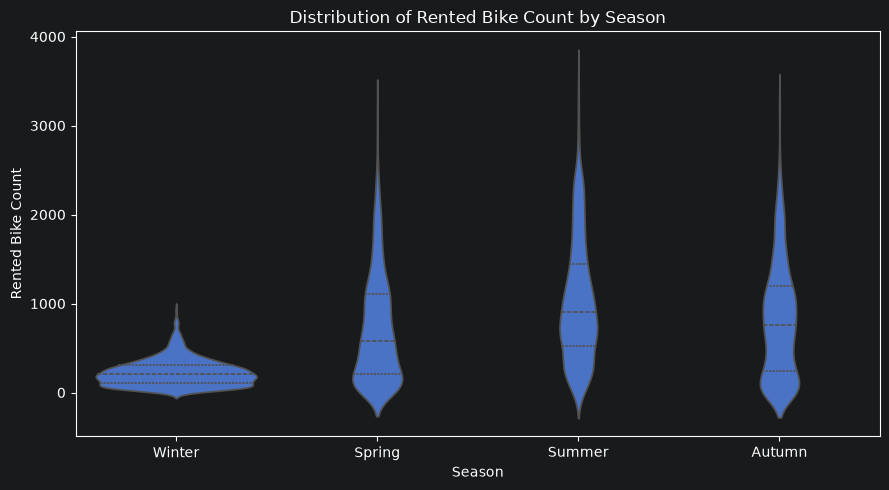

In [34]:
# make violin plot by season
plt.figure(figsize=(9, 5))                                     ##
sns.violinplot(data=bike_data,x="season",y="rented_count",order=season_order,inner="quartile")
plt.title("Distribution of Rented Bike Count by Season")       ##
plt.xlabel("Season")                                           ##
plt.ylabel("Rented Bike Count")                                ##
plt.tight_layout()                                             ##
plt.show()                                                     ##

#### 6.3.5 pie chart

i will use a pie chart to show the percentage of holiday and regular day observations in the dataset

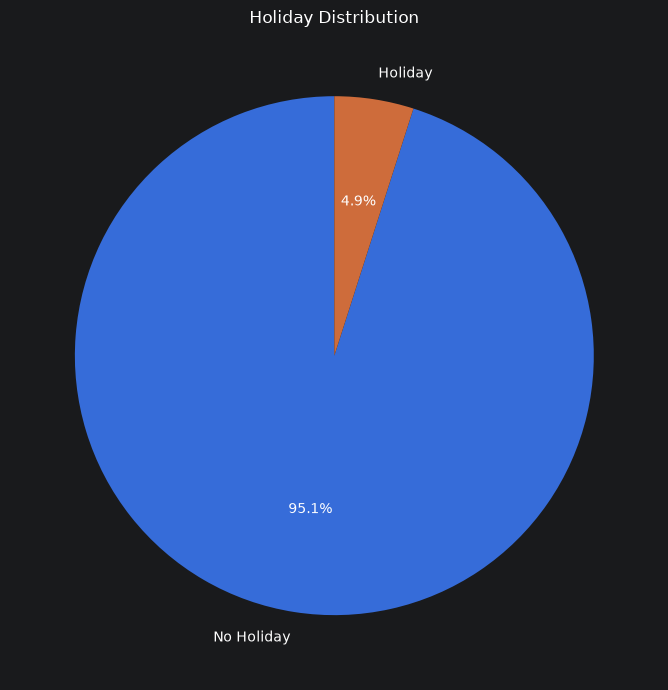

In [35]:
# count holiday values
holiday_counts = bike_data["holiday"].value_counts()  ##
# make pie chart
plt.figure(figsize=(7, 7))                            ##
plt.pie(holiday_counts,labels=holiday_counts.index,autopct="%1.1f%%",startangle=90)
plt.title("Holiday Distribution")                     ##
plt.tight_layout()                                    ##
plt.show()                                            ##

#### findings from the pie chart

the pie chart shows that most observations are regular days

about 95% of the observations are marked as No Holiday, while only about 5% are holidays

this means that the holiday categories are not balanced. because holidays are rare, their results should be interpreted carefully

#### 6.3.6 pairplot

a pairplot shows several relationships and distributions in one figure

i will use a sample of the dataset because a pairplot with all 8,760 rows may be slow and difficult to read

i will focus on rented bike count, temperature, humidity, wind speed and solar radiation

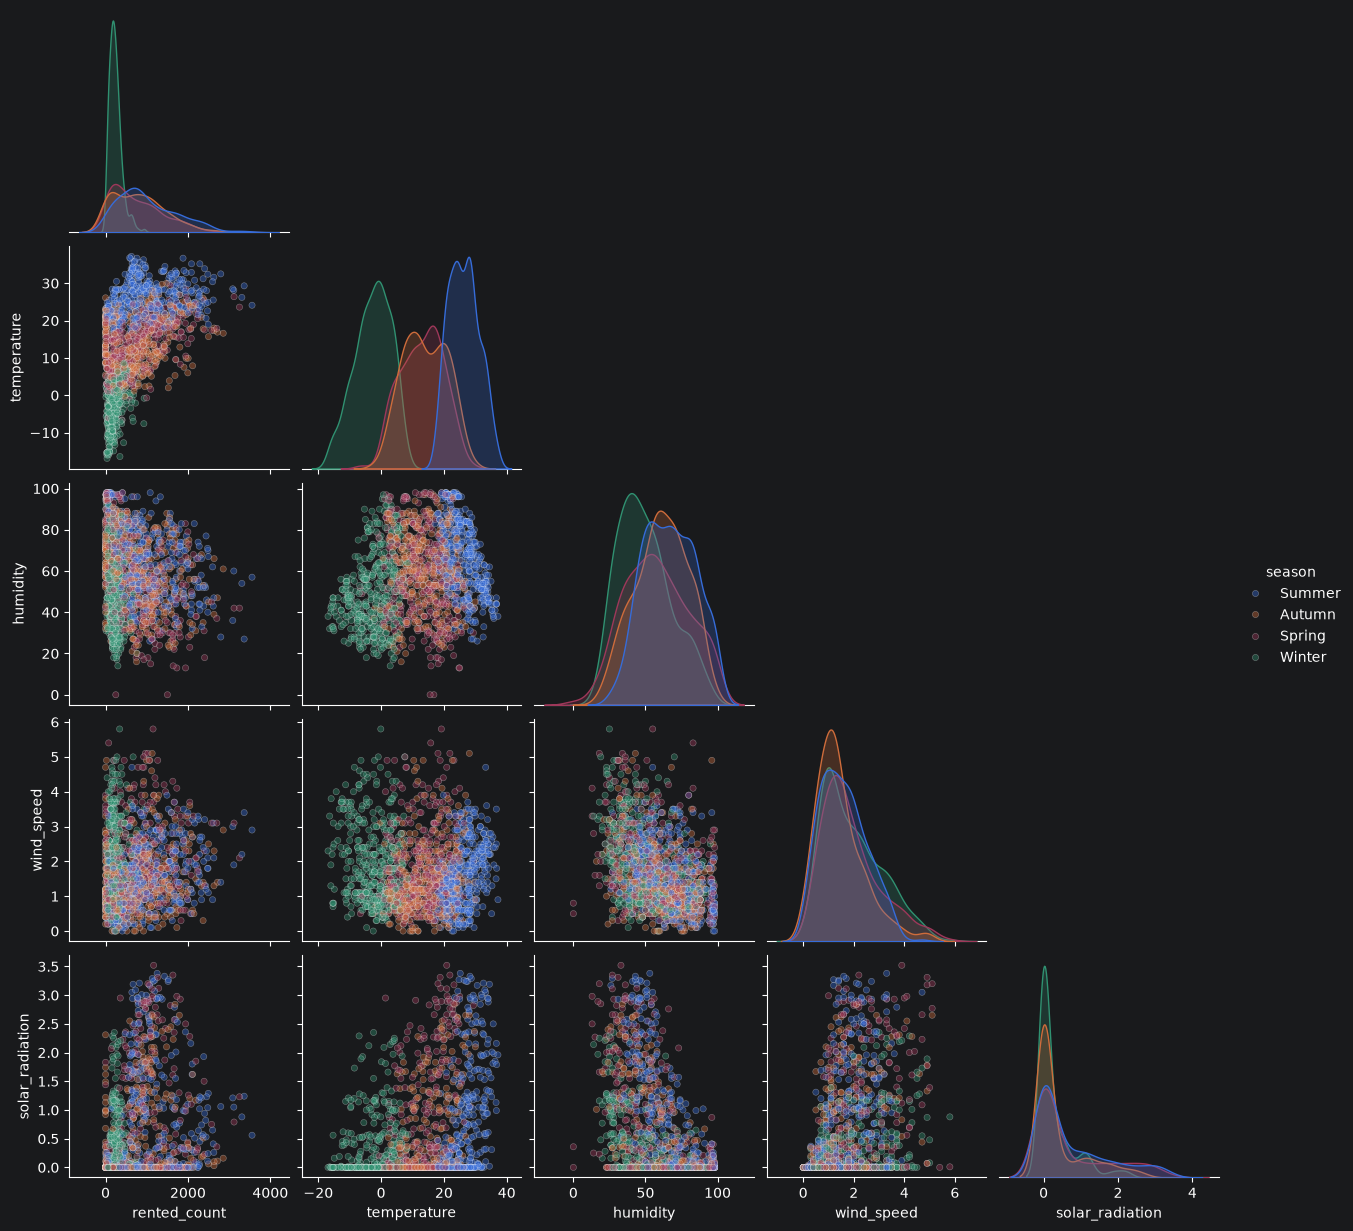

In [36]:
# choose columns for pairplot
pairplot_columns = ["rented_count","temperature", "humidity","wind_speed", "solar_radiation","season"]

# use a smaller sample to keep the graph clear
pairplot_sample = bike_data[pairplot_columns].sample(n=1500,random_state=42)

# make pairplot and compare between seasons
sns.pairplot(                                                                         ##
    pairplot_sample,                                                                  ##
    vars=["rented_count","temperature","humidity","wind_speed","solar_radiation"],    ##
    hue="season",corner=True,plot_kws={"alpha": 0.4, "s": 20})
plt.show()                                                                            ##

#### findings from the pairplot

the pairplot shows clear differences between the seasons

winter observations are mostly connected with lower temperatures and lower rented bike counts

summer observations usually have higher temperatures and higher rental values. Autumn and spring are more spread between the winter and summer values

the relationship between temperature and rented bike count looks positive, but the points are still widely spread. This means that temperature is related to bike demand, but it is not the only factor

humidity seems to have a weak negative relationship with rented bike count. higher rental values appear more often when humidity is lower or medium

wind speed does not show a clear relationship with rented bike count

solar radiation contains many zero values, especially during nighttime. positive solar radiation values appear more often during warmer seasons

the pairplot supports the earlier results from the correlation tables and the seasonal graphs

## 7. index analysis

in this section, I will check the index of the dataset

i will check if the current index is unique, whether it is based on time and whether the data is sorted

In [37]:
# check the current index
print("Index is unique:", bike_data.index.is_unique)                                     ##
print("Index type:", type(bike_data.index))                                              ##
print("Data is sorted by date:", bike_data["date"].is_monotonic_increasing)              ##
#---------------------------------------------------------------
# check if rows are sorted by date and hour
sorted_by_time = bike_data.sort_values(by=["date", "hour"])

same_order = bike_data[["date", "hour"]].reset_index(drop=True).equals(sorted_by_time[["date", "hour"]].reset_index(drop=True))                                                                                        ##

print("Data is sorted by date and hour:", same_order)                                    ##
#----------------------------------------------------------------
# create one datetime column from date and hour
bike_data["datetime"] = (bike_data["date"] +pd.to_timedelta(bike_data["hour"],unit="h")) ##

# check the new datetime values
print("Datetime values are unique:",bike_data["datetime"].is_unique)
print("Datetime values are sorted:",bike_data["datetime"].is_monotonic_increasing)

Index is unique: True
Index type: <class 'pandas.RangeIndex'>
Data is sorted by date: True
Data is sorted by date and hour: True
Datetime values are unique: True
Datetime values are sorted: True


### 7.1 index findings

the current index is unique, but it is a regular RangeIndex and is not based on time

the dataset is already sorted by date and hour

after combining the date and hour columns, each datetime value is unique. this means that every row represents one specific hour and there are no repeated hourly observations

the datetime values are also sorted from the earliest hour to the latest hour

a datetime index may be more useful than the original index for time-based analysis

### 7.2 changes over time

since the dataset covers one full year, i will check whether the average number of rented bikes changes between months.

i will use the datetime column as an index and calculate the average rented bike count for each month.

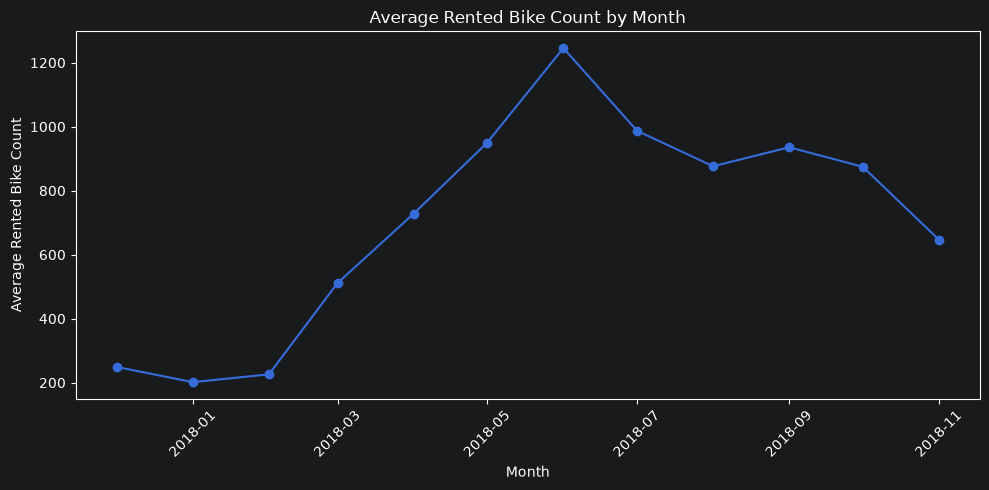

In [38]:
# use datetime as the index
time_data = bike_data.set_index("datetime").sort_index()

# calculate average rentals for each month
monthly_average_rentals = (time_data["rented_count"].resample("MS").mean())       ##
monthly_average_rentals.round(2)                                                  ##
#---------------------------------------------------
# make monthly average graph
plt.figure(figsize=(10, 5))                                                       ##
plt.plot(monthly_average_rentals.index,monthly_average_rentals.values,marker="o") ##
plt.title("Average Rented Bike Count by Month")                                   ##
plt.xlabel("Month")                                                               ##
plt.ylabel("Average Rented Bike Count")                                           ##
plt.xticks(rotation=45)                                                           ##
plt.tight_layout()                                                                ##
plt.show()                                                                        ##

## 8. insights and data story

### 8.1 main insights

the analysis shows that bike rental demand changes a lot depending on the time of the year and the weather conditions

the first main insight is that bike rentals are strongly connected to the season. Summer has the highest rental demand, while winter has the lowest demand. about 52% of the summer observations are in the high rental group, while about 66% of the winter observations are in the low rental group

the monthly analysis shows a similar pattern. the average number of rented bikes is low during winter, increases during spring and reaches its highest point around June. After that, the demand slowly decreases toward the end of the year

the second main insight is that temperature has the strongest positive correlation with rented bike count. the Pearson correlation is about 0.54, which means that warmer hours usually have more bike rentals. however, temperature alone does not fully explain the demand because the scatterplot still contains a wide spread of values

the third main insight is that rainfall, snowfall and humidity generally have a negative relationship with bike rentals. the relationships are not very strong, but the results suggest that people are less likely to rent bikes during wet or uncomfortable weather

the fourth insight is that holidays and system activity also matter. holidays contain a higher percentage of low-demand observations than regular days. also, every non-functioning observation belongs to the low rental group because no bikes were rented when the system was not operating

### 8.2 biases and risks

one important limitation is that the dataset only contains information from Seoul and only covers one year

because of this, the results may not represent other cities or other years. A city with different weather, public transportation or cycling infrastructure may have very different rental patterns

the original data collection process is also not fully explained. this means that we do not know all the details about the sensors, measurement limits or possible technical problems

for example, many visibility values are equal to 2,000. this may be the maximum value recorded by the system, but the dataset does not clearly confirm this

the dataset is also unbalanced in some categorical variables. holidays and non-functioning days are rare compared to regular functioning days, so conclusions about these smaller groups should be made carefully

another risk is confusing correlation with causation. temperature is related to bike rentals, but this does not prove that temperature alone causes the change. Other factors, such as season, daylight and working hours, may change at the same time

### 8.3 possible failure points

using the overall average rented bike count may give a misleading result because bike demand changes a lot between seasons and hours

a system that predicts the same demand during winter and summer would probably make large mistakes

the hour variable should also be handled carefully. jour is circular because hour 23 is close to hour 0, even though their numerical values look far apart

removing all detected outliers could also cause problems. some high rental values may represent real busy hours, while high rainfall or snowfall values may represent real weather events

non-functioning days should not be treated as normal low-demand days. the rental count is zero because the system was not operating, not necessarily because nobody wanted to rent a bike

a statistical or engineering model should also consider that several weather variables are connected to each other. for example, temperature and dew point temperature have a very strong correlation and may contain similar information

### 8.4 what i learned

before this analysis, i mainly thought that exploratory data analysis was about creating graphs and calculating averages

during the work, i learned that it is also important to understand how the data was collected, check its quality and think about the meaning behind unusual values

i also learned that an outlier is not always a mistake. Some unusual values may represent real events that are important for the analysis

another thing i learned is that one statistical measure is usually not enough. For example, the mean rented bike count is much higher than the median because the distribution is skewed

my view changed because i now understand that data is not automatically the truth. The results depend on what was measured, what was not included and how the data is interpreted

overall, the dataset shows that bike rental demand is connected to season, temperature, weather and whether the system is functioning. a useful prediction model would need to combine several of these factors instead of using only one variable

## 9. bonus

### 9.1 feature engineering

feature engineering means creating new columns from the existing data.

since the dataset contains date and hour information, i will create new time-related features:

- month
- day of the week
- weekend or weekday
- time of day
- rush hour

these features may help explain bike rental patterns more clearly.

In [39]:
# create time features
bike_data["month"] = bike_data["datetime"].dt.month                             ##
bike_data["day_name"] = bike_data["datetime"].dt.day_name()
# mark weekends
bike_data["is_weekend"] = bike_data["day_name"].isin(["Saturday", "Sunday"])
# split hours into parts of the day
bike_data["time_of_day"] = pd.cut(                                              ##
    bike_data["hour"],                                                          ##
    bins=[-1, 5, 11, 16, 20, 23],                                               ##
    labels=["Night","Morning","Afternoon","Evening","Late Night"])

# mark rush hours
rush_hours = [7, 8, 9, 17, 18, 19]                                              ##
bike_data["is_rush_hour"] = bike_data["hour"].isin(rush_hours)
# show the new columns
bike_data[["datetime","month","day_name","is_weekend","time_of_day","is_rush_hour"]].head(10)       ##

,datetime,month,day_name,is_weekend,time_of_day,is_rush_hour
0,2017-12-01 00:00:00,12,Friday,False,Night,False
1,2017-12-01 01:00:00,12,Friday,False,Night,False
2,2017-12-01 02:00:00,12,Friday,False,Night,False
3,2017-12-01 03:00:00,12,Friday,False,Night,False
4,2017-12-01 04:00:00,12,Friday,False,Night,False
5,2017-12-01 05:00:00,12,Friday,False,Night,False
6,2017-12-01 06:00:00,12,Friday,False,Morning,False
7,2017-12-01 07:00:00,12,Friday,False,Morning,True
8,2017-12-01 08:00:00,12,Friday,False,Morning,True
9,2017-12-01 09:00:00,12,Friday,False,Morning,True


the new features were created from the datetime and hour columns

the month and day_name columns can help find monthly and weekly patterns

the is_weekend column separates weekends from regular weekdays

the time_of_day column divides the hours into easier groups

the is_rush_hour column marks common morning and evening commuting hours. these rush hours are an assumption used for the analysis and are not provided directly by the original dataset

### 9.2 rental demand by time of day

i will compare the average rented bike count between the different parts of the day

In [40]:
# calculate average rentals for each part of the day
average_rentals_by_time = (bike_data.groupby("time_of_day",observed=False)["rented_count"].mean()) ##
average_rentals_by_time.round(2)    ##



time_of_day
Night          290.71
Morning        613.99
Afternoon      790.26
Evening       1226.39
Late Night     875.12
Name: rented_count, dtype: float64

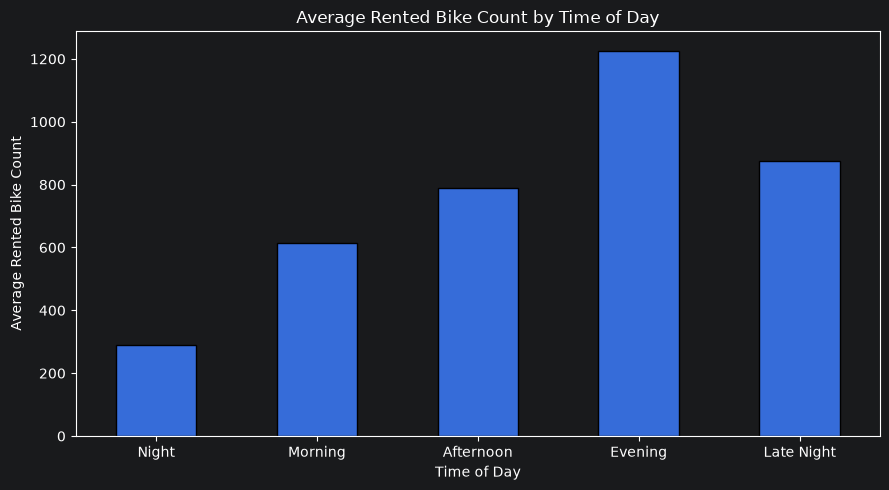

In [41]:
# make bar chart for average rentals by time of day
plt.figure(figsize=(9, 5))                                  ##

average_rentals_by_time.plot(kind="bar",edgecolor="black")  ##

plt.title("Average Rented Bike Count by Time of Day")       ##
plt.xlabel("Time of Day")                                   ##
plt.ylabel("Average Rented Bike Count")                     ##
plt.xticks(rotation=0)                                      ##
plt.tight_layout()                                          ##
plt.show()                                                  ##

### 9.3 findings from the time of day analysis

the average bike demand changes clearly between different parts of the day

night has the lowest average demand, with about 291 rented bikes per hour

the average demand increases during the morning and afternoon. evening has the highest average, with about 1,226 rented bikes per hour

late night demand is lower than evening demand, but it is still higher than the morning and afternoon averages

this pattern may be connected to commuting, work schedules and people using bikes for activities after work. however, the dataset does not contain the reason for each rental, so this is only a possible explanation

### 9.4 rush Hour analysis

i marked the hours 7, 8, 9, 17, 18 and 19 as possible rush hours

i will compare the average rented bike count during rush hours and non-rush hours

In [42]:
# compare rush and non rush hours
rush_hour_summary = (bike_data.groupby("is_rush_hour")["rented_count"].agg(["count", "mean", "median", "std"]).round(2))
# rename the groups
rush_hour_summary.index = ["Non-Rush Hour","Rush Hour"] ##

rush_hour_summary                                       ##

,count,mean,median,std
Non-Rush Hour,6570,600.34,409.0,542.34
Rush Hour,2190,1017.38,825.0,807.15


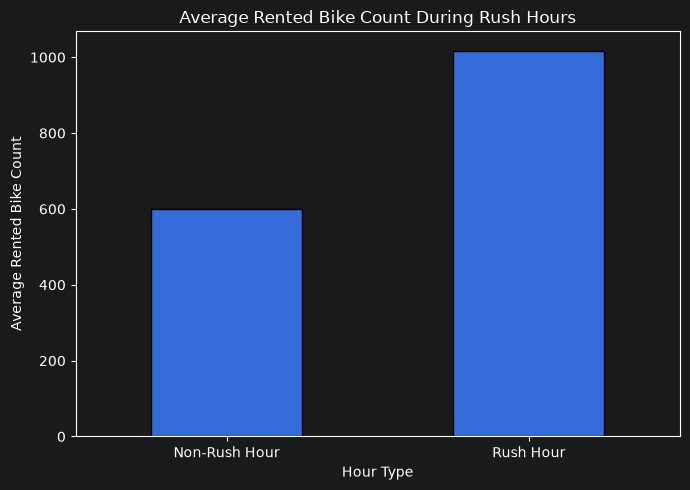

In [43]:
# calculate average rentals for rush and non rush hours
average_rentals_by_rush_hour = (bike_data.groupby("is_rush_hour")["rented_count"].mean()) ##
average_rentals_by_rush_hour.index = ["Non-Rush Hour","Rush Hour"] ##

# make bar chart for the comparison
plt.figure(figsize=(7, 5))                                         ##
average_rentals_by_rush_hour.plot(kind="bar",edgecolor="black")    ##
plt.title("Average Rented Bike Count During Rush Hours")           ##
plt.xlabel("Hour Type")                                            ##
plt.ylabel("Average Rented Bike Count")                            ##
plt.xticks(rotation=0)                                             ##
plt.tight_layout()                                                 ##
plt.show()                                                         ##

### 9.5 findings from the rush hour analysis

the average rented bike count during rush hours is about 1,017 bikes per hour

during non-rush hours, the average is about 600 bikes per hour

the median is also higher during rush hours: 825 bikes compared to 409 bikes during non-rush hours

this shows that bike demand is much higher during the hours marked as rush hours

the standard deviation is also higher during rush hours. this means that rental demand changes more between different rush-hour observations

the rush-hour definition was created for this analysis and was not included in the original dataset, so the result depends on the hours I selected

### 9.6 hypothesis test

i will test whether the average rented bike count is higher during rush hours than during non-rush hours

only functioning days will be included in the test

The hypotheses are:

- H0:The average rented bike count during rush hours is equal to or lower than the average during non-rush hours
- H1: The average rented bike count during rush hours is higher than the average during non-rush hours

i will use Welch's t-test because the two groups have different sizes and different standard deviations

the significance level will be 0.05

In [44]:
# import t test
from scipy.stats import ttest_ind                                      ##
# use only functioning days
functioning_data = bike_data[bike_data["functioning_day"] == "Yes"]    ##
# split rush and non rush rentals
rush_hour_rentals = functioning_data.loc[functioning_data["is_rush_hour"],"rented_count"]      ##

non_rush_hour_rentals = functioning_data.loc[~functioning_data["is_rush_hour"],"rented_count"] ##
# run welch t test
t_statistic, p_value = ttest_ind(rush_hour_rentals,non_rush_hour_rentals,equal_var=False,alternative="greater" ##
)

print("Rush hour mean:", round(rush_hour_rentals.mean(), 2))           ##
print("Non-rush hour mean:", round(non_rush_hour_rentals.mean(), 2))   ##
print("T-statistic:", round(t_statistic, 3))                           ##
print("P-value:", p_value)                                             ##

Rush hour mean: 1051.96
Non-rush hour mean: 621.44
T-statistic: 23.119
P-value: 1.2043584460256392e-108


### 9.7 hypothesis test results

the average rented bike count during rush hours is about 1,052 bikes per hour

during non-rush hours, the average is about 621 bikes per hour

the p-value is much smaller than the significance level of 0.05

because of this, i reject the null hypothesis

the results give strong statistical evidence that the average rented bike count is higher during the hours marked as rush hours

however, this test only shows a difference between the groups. it does not prove that rush hour itself is the only reason for the higher demand. other factors, such as hour of the day, work schedules, weather and season, may also affect the number of rentals

### 9.8 suggestions for further research

this analysis found several patterns, but there are more questions that could be studied in the future

one possible direction is to compare bike rental demand between weekdays and weekends. this may show whether people mainly use the bikes for work or for free-time activities

another direction is to analyze the exact hourly pattern. it may be useful to check whether there are separate demand peaks in the morning and evening

the effect of rainfall could also be studied in more detail. instead of only checking the correlation, future research could compare dry hours, light rain and heavy rain

it would also be useful to include information that is not available in this dataset, such as public events, traffic conditions, public transportation problems and the location of bike stations

the dataset only covers one year. using data from several years could help check whether the same seasonal and weather patterns repeat over time

finally, a future project could build a machine learning model that predicts the rented bike count using time, weather and calendar information